# Retail Sales Pipeline: End-to-End Data Cleaning & Analytics Engine

**Author:** Mirza Ishtiyaq Baig *(Data Analyst / Analytics Engineer)*  
**Architecture:** Production-Grade Modular Data Pipeline (Ingestion -> Cleansing -> Integration -> Analytics -> Reporting)

---

## Pipeline Architecture Overview
This notebook implements a modular, production-ready data cleaning and analytics workflow for multi-source retail datasets (`customers.csv`, `orders.csv`, `transactions.csv`). It addresses raw data quality challenges including primary key deduplication, categorical string normalization, missing value imputation, and fulfillment SLA anomaly detection.

## 1. System Setup & Dependencies

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Set global plotting parameters for production visualizations
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.edgecolor'] = '#cccccc'
plt.rcParams['axes.linewidth'] = 0.8

# Define raw data file paths
DATA_DIR = '../data/raw/'
REPORTS_DIR = '../reports/figures/'
os.makedirs(REPORTS_DIR, exist_ok=True)

print('Dependencies loaded successfully.')

Dependencies loaded successfully.


## 2. Data Ingestion & Schema Auditing

In [2]:
# Ingest raw CSV extracts
# customers.csv contains one non-UTF-8 byte (a Windows-1252/Latin-1 "ü" in the "Anna Müller"
# row), so it is read with a permissive encoding; orders.csv and transactions.csv are clean UTF-8.
customers_raw = pd.read_csv(os.path.join(DATA_DIR, 'customers.csv'), encoding='latin-1')
orders_raw = pd.read_csv(os.path.join(DATA_DIR, 'orders.csv'))
transactions_raw = pd.read_csv(os.path.join(DATA_DIR, 'transactions.csv'))

print('Ingestion Audit:')
print(f'Raw Customers Shape   : {customers_raw.shape}')
print(f'Raw Orders Shape      : {orders_raw.shape}')
print(f'Raw Transactions Shape: {transactions_raw.shape}')

Ingestion Audit:
Raw Customers Shape   : (20, 9)
Raw Orders Shape      : (52, 8)
Raw Transactions Shape: (23, 4)


## 3. Modular Data Cleansing Engine

In [3]:
def deduplicate_entities(df: pd.DataFrame, id_col: str) -> pd.DataFrame:
    """Deduplicate entity records based on primary key constraints."""
    initial_count = len(df)
    cleaned_df = df.drop_duplicates(subset=[id_col], keep='first').copy()
    dropped_count = initial_count - len(cleaned_df)
    print(f'[{id_col}] Deduplication: {initial_count} -> {len(cleaned_df)} rows ({dropped_count} duplicates removed)')
    return cleaned_df

# Execute primary key deduplication
customers_clean = deduplicate_entities(customers_raw, 'customer_id')
orders_clean = deduplicate_entities(orders_raw, 'order_id')
transactions_clean = deduplicate_entities(transactions_raw, 'transaction_id')

[customer_id] Deduplication: 20 -> 16 rows (4 duplicates removed)
[order_id] Deduplication: 52 -> 52 rows (0 duplicates removed)
[transaction_id] Deduplication: 23 -> 23 rows (0 duplicates removed)


In [4]:
def impute_missing(df: pd.DataFrame, fill_values: dict) -> pd.DataFrame:
    """Fill missing (NaN) values column-by-column with explicit fallbacks.

    Rows are kept rather than dropped: a blank optional contact field (email, phone,
    city) has no bearing on whether an order/revenue record is trustworthy, so dropping
    the row would destroy valid financial data just to "fix" a field nothing downstream
    aggregates on.
    """
    df = df.copy()
    for col, fallback in fill_values.items():
        if col in df.columns:
            df[col] = df[col].fillna(fallback)
    return df

# Impute missing contact attributes without dropping revenue-bearing rows
customers_clean = impute_missing(customers_clean, {
    'email': 'Not Provided',
    'phone_primary': 'Not Provided',
    'phone_secondary': 'Not Provided',
    'city': 'Unknown',
})
orders_clean = impute_missing(orders_clean, {'email': 'Not Provided'})

print('Missing value imputation completed.')

Missing value imputation completed.


In [5]:
def standardize_countries(df: pd.DataFrame, column: str, mapping: dict) -> pd.DataFrame:
    """Collapse free-text country variants onto a single canonical label per country.

    `mapping` only covers the raw variants actually observed in customers.csv (casing,
    abbreviations, punctuation) -- it is a targeted cleanup dictionary, not a general
    ISO-3166 lookup table.
    """
    df = df.copy()
    df[column] = df[column].replace(mapping)
    return df

# Categorical string standardization map for geographic attributes
country_map = {
    'United States': 'USA', 'usa': 'USA', 'US': 'USA', 'U.S.A.': 'USA', 'UNITED STATES': 'USA',
    'United Kingdom': 'UK', 'United kingdom': 'UK', 'united kingdom': 'UK', 'Great Britain': 'UK',
    'United Arab Emirates': 'UAE'
}

customers_clean = standardize_countries(customers_clean, 'country', country_map)
print('Categorical country standardization completed. Unique countries:')
print(customers_clean['country'].unique())

Categorical country standardization completed. Unique countries:
<StringArray>
['USA', 'UK', 'Germany', 'Mexico', 'UAE', 'Japan', 'Canada']
Length: 7, dtype: str


## 4. Relational Data Integration & Schema Alignment

In [6]:
def filter_to_known_customers(df: pd.DataFrame, valid_ids: set, id_col: str = 'customer_id'):
    """Split a table into (matched, orphaned) rows based on a foreign-key column.

    transactions.csv carries only customer_id (no order_id), so it cannot be joined to
    orders directly. Merging orders and transactions on customer_id alone would fan out
    into a full cross-product per customer -- every order paired with every transaction
    for that customer -- silently inflating summed/averaged metrics. Transactions are
    therefore validated against the customer master and analyzed on their own below,
    instead of being merged into the orders master.
    """
    is_known = df[id_col].isin(valid_ids)
    return df[is_known].copy(), df[~is_known].copy()

# Resolve column name collision prior to relational merge
transactions_clean = transactions_clean.rename(columns={'purchase_amount': 'transaction_amount'})

# Customer <-> Order master (one row per order; no fan-out risk since each order has
# exactly one customer_id and orders/customers are both already deduplicated)
full_data = pd.merge(customers_clean, orders_clean, on='customer_id', how='left')

# Validate transactions against the cleaned customer master rather than merging them in
transactions_matched, transactions_orphaned = filter_to_known_customers(
    transactions_clean, set(customers_clean['customer_id'])
)
if len(transactions_orphaned):
    print(f'Excluded {len(transactions_orphaned)} orphan transaction(s) with unknown customer_id: '
          f'{transactions_orphaned["customer_id"].tolist()} '
          f'(amounts: {transactions_orphaned["transaction_amount"].tolist()})')

print(f'Master Order Analytical Schema Shape: {full_data.shape}')
print('Columns in Master Dataset:', full_data.columns.tolist())

Excluded 3 orphan transaction(s) with unknown customer_id: ['C892', 'C445', 'C113'] (amounts: [100000.0, 95500.0, -150.0])
Master Order Analytical Schema Shape: (49, 16)
Columns in Master Dataset: ['customer_id', 'customer_name', 'email_x', 'phone_primary', 'phone_secondary', 'city', 'country', 'created_date', 'purchase_amount', 'order_id', 'email_y', 'order_date', 'ship_date', 'quantity', 'unit_price', 'total_amount']


## 5. Temporal Lead-Time Arithmetic & Anomaly Detection

In [7]:
# Convert temporal strings to datetime objects
full_data['order_date'] = pd.to_datetime(full_data['order_date'])
full_data['ship_date'] = pd.to_datetime(full_data['ship_date'])

# Calculate fulfillment lead-time duration in days
full_data['ship_days'] = (full_data['ship_date'] - full_data['order_date']).dt.days

# Flag negative lead-time anomalies (ship_date logged before order_date -- a sync/entry
# error, not a physically possible fulfillment) directly on the master frame so the flag
# travels with the record for any downstream audit or export.
full_data['anomaly_flag'] = full_data['ship_days'] < 0

valid_shipments = full_data[~full_data['anomaly_flag']]
anomalous_shipments = full_data[full_data['anomaly_flag']]

print(f'Total Master Records    : {len(full_data)}')
print(f'Valid Fulfillment Logs  : {len(valid_shipments)}')
print(f'Flagged Negative Days   : {len(anomalous_shipments)}')
print(f'Clean Avg Shipping Lead : {valid_shipments["ship_days"].mean():.2f} days')
print(f'Clean Shipping Range    : {valid_shipments["ship_days"].min()}-{valid_shipments["ship_days"].max()} days')

print('\n=== ANOMALY AUDIT: Negative Lead-Time Records (flagged for IT sync review) ===')
anomaly_audit = anomalous_shipments[
    ['customer_id', 'order_id', 'order_date', 'ship_date', 'ship_days', 'anomaly_flag']
].reset_index(drop=True)
print(anomaly_audit.to_string(index=False))

Total Master Records    : 49
Valid Fulfillment Logs  : 40
Flagged Negative Days   : 9
Clean Avg Shipping Lead : 2.92 days
Clean Shipping Range    : 2-3 days

=== ANOMALY AUDIT: Negative Lead-Time Records (flagged for IT sync review) ===
customer_id order_id order_date  ship_date  ship_days  anomaly_flag
       C001    O3006 2024-03-23 2024-03-22         -1          True
       C002    O3001 2024-02-11 2024-02-09         -2          True
       C005    O3007 2024-02-14 2024-02-12         -2          True
       C006    O3002 2024-04-02 2024-03-30         -3          True
       C007    O3009 2024-03-01 2024-02-27         -3          True
       C010    O3003 2024-02-23 2024-02-20         -3          True
       C012    O3005 2024-03-26 2024-03-24         -2          True
       C013    O3004 2024-04-06 2024-04-04         -2          True
       C014    O3008 2024-02-08 2024-02-06         -2          True


## 6. Business Key Metrics & Exploratory Analytics

In [8]:
# Business KPI Aggregations
# AOV is computed on the order-level master (full_data); ATV is computed on transactions_matched
# directly rather than a merged frame -- see the fan-out note in the integration step above.
total_revenue = full_data['total_amount'].sum()
avg_order_val = full_data['total_amount'].mean()
avg_transaction_val = transactions_matched['transaction_amount'].mean()
total_units_sold = full_data['quantity'].sum()

print('=== EXECUTIVE FINANCIAL SUMMARY ===')
print(f'Total Gross Revenue       : ${total_revenue:,.2f}')
print(f'Average Order Value (AOV) : ${avg_order_val:,.2f}')
print(f'Average Transaction Value : ${avg_transaction_val:,.2f}')
print(f'Total Units Sold          : {total_units_sold:,}')

=== EXECUTIVE FINANCIAL SUMMARY ===
Total Gross Revenue       : $3,826.12
Average Order Value (AOV) : $78.08
Average Transaction Value : $107.77
Total Units Sold          : 64


In [9]:
# Top 5 Customers by Revenue
top_customers = (full_data.groupby('customer_name')['total_amount']
                          .sum()
                          .sort_values(ascending=False)
                          .head(5)
                          .reset_index())
top_customers.columns = ['Customer', 'Total Spent']

# Revenue Breakdown by Country
country_revenue = (full_data.groupby('country')['total_amount']
                            .sum()
                            .sort_values(ascending=False)
                            .reset_index())
country_revenue.columns = ['Country', 'Total Revenue']

# Monthly Revenue Velocity
full_data['financial_month'] = full_data['order_date'].dt.to_period('M')
monthly_revenue = (full_data.groupby('financial_month')['total_amount']
                             .sum()
                             .reset_index())
monthly_revenue.columns = ['Month', 'Monthly Revenue']

print('Top 5 Spenders:')
print(top_customers)
print('\nRevenue by Country:')
print(country_revenue)

Top 5 Spenders:
           Customer  Total Spent
0        Olivia Lee       670.00
1       Priya Patel       513.65
2       Ethan Clark       384.50
3  Fatima Al-Hassan       366.50
4       Yuki Tanaka       361.00

Revenue by Country:
   Country  Total Revenue
0      USA        1140.57
1       UK        1023.55
2   Canada         670.00
3      UAE         366.50
4    Japan         361.00
5  Germany         160.00
6   Mexico         104.50


## 7. Executive Data Visualization Dashboard

Executive dashboard visualization saved successfully to: ../reports/figures/sales_pipeline_summary.png


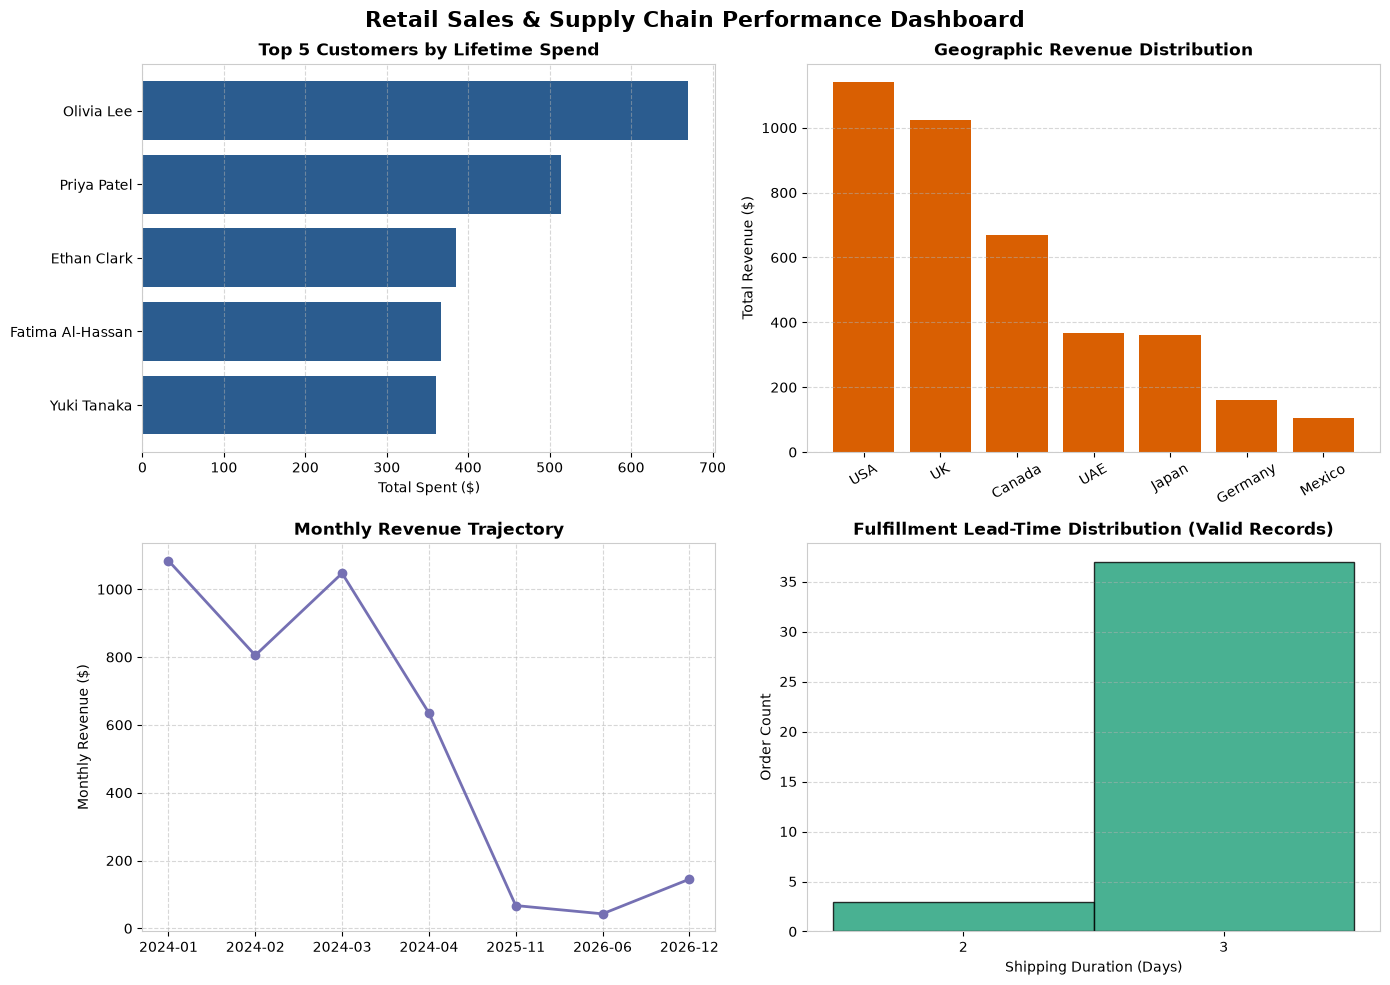

In [10]:
# Construct 2x2 Production Dashboard
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Retail Sales & Supply Chain Performance Dashboard', fontsize=16, fontweight='bold')

# Chart 1: Top 5 Spenders
axes[0, 0].barh(top_customers['Customer'], top_customers['Total Spent'], color='#2b5c8f')
axes[0, 0].set_title('Top 5 Customers by Lifetime Spend', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Total Spent ($)')
axes[0, 0].invert_yaxis()
axes[0, 0].grid(axis='x', linestyle='--', alpha=0.5)

# Chart 2: Revenue by Country
axes[0, 1].bar(country_revenue['Country'], country_revenue['Total Revenue'], color='#d95f02')
axes[0, 1].set_title('Geographic Revenue Distribution', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Total Revenue ($)')
axes[0, 1].tick_params(axis='x', rotation=30)
axes[0, 1].grid(axis='y', linestyle='--', alpha=0.5)

# Chart 3: Monthly Revenue Velocity
months_str = monthly_revenue['Month'].astype(str)
axes[1, 0].plot(months_str, monthly_revenue['Monthly Revenue'], marker='o', color='#7570b3', linewidth=2)
axes[1, 0].set_title('Monthly Revenue Trajectory', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Monthly Revenue ($)')
axes[1, 0].grid(True, linestyle='--', alpha=0.5)

# Chart 4: Shipping Days Distribution
# Bins are aligned to integer days (rather than a fixed bin count) since ship_days is a
# small set of discrete integers -- fixed-width binning over a narrow range would produce
# misleading, mostly-empty bars.
ship_day_min, ship_day_max = int(valid_shipments['ship_days'].min()), int(valid_shipments['ship_days'].max())
day_bins = range(ship_day_min, ship_day_max + 2)
axes[1, 1].hist(valid_shipments['ship_days'], bins=day_bins, color='#1b9e77', edgecolor='black', alpha=0.8, align='left')
axes[1, 1].set_xticks(range(ship_day_min, ship_day_max + 1))
axes[1, 1].set_title('Fulfillment Lead-Time Distribution (Valid Records)', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Shipping Duration (Days)')
axes[1, 1].set_ylabel('Order Count')
axes[1, 1].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
output_path = os.path.join(REPORTS_DIR, 'sales_pipeline_summary.png')
plt.savefig(output_path, dpi=300)
print(f'Executive dashboard visualization saved successfully to: {output_path}')
plt.show()